# El Impuesto Silencioso: Análisis de la Inflación y Pérdida de Poder Adquisitivo en Perú (2018-2024)

Este análisis económico, basado en datos de la API oficial del Banco Central de Reserva del Perú (BCRP) y hasta octubre de 2023, mide el efecto real que tuvo la crisis inflacionaria más reciente sobre los ahorros peruanos.

### 1. Principales hallazgos (TL;DR)
La conclusión más relevante de nuestro proceso de datos es la siguiente, antes de examinar las dinámicas estructurales:


- **Efecto grave en la riqueza local:** Desde el comienzo de la pandemia (2018) hasta finales de 2024, un ahorrador peruano vio disminuir el valor real de su dinero en cerca del **22.4%**.
- **El máximo histórico (8.81%):** En el año 2022, en la mitad del periodo, el IPC (índice de precios al consumidor) llegó a cotas alarmantes por el desplome logístico a nivel mundial y la subida de las materias primas, lo que rompió el rango objetivo del Banco Central.
- **Recuperación Macroeconómica:** A medida que el análisis se aproximaba a su final (2024), una política monetaria restrictiva y agresiva del BCRP logró reducir la inflación a niveles normales (por debajo del 3%). Sin embargo, el daño al poder adquisitivo inicial ya es definitivo.

In [1]:
# ⚙️ [MOTOR DE DATOS] Conexión silenciosa a la API del BCRP para alimentar gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import json
import ssl
import datetime

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

def extraer_bcrp(serie: str, inicio: str, fin: str) -> pd.DataFrame:
    url = f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/{serie}/json/{inicio}/{fin}"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, context=ctx) as response:
        data = json.loads(response.read().decode())
    registros = []
    for p in data["periods"]:
        mes_es, anio = p["name"].split(".")
        meses = {"Ene": "01", "Feb": "02", "Mar": "03", "Abr": "04",
                 "May": "05", "Jun": "06", "Jul": "07", "Ago": "08",
                 "Sep": "09", "Oct": "10", "Nov": "11", "Dic": "12"}
        fecha = f"{anio}-{meses[mes_es]}-01"
        registros.append({"fecha": fecha, "valor": float(p["values"][0])})
    df = pd.DataFrame(registros)
    df["fecha"] = pd.to_datetime(df["fecha"])
    return df

# 1. Descarga vía MLOps Pipeline
df_inflacion = extraer_bcrp("PN01273PM", "2018-01", "2024-12").rename(columns={"valor": "inflacion_anual"})
df_ipc = extraer_bcrp("PN38705PM", "2018-01", "2024-12").rename(columns={"valor": "indice_precios"})

# 2. Unir y calcular métrica económica base 100
clean = pd.merge(df_inflacion, df_ipc, on="fecha")
ipc_base = clean["indice_precios"].iloc[0]
clean["poder_adquisitivo_base100"] = 100 * (ipc_base / clean["indice_precios"])

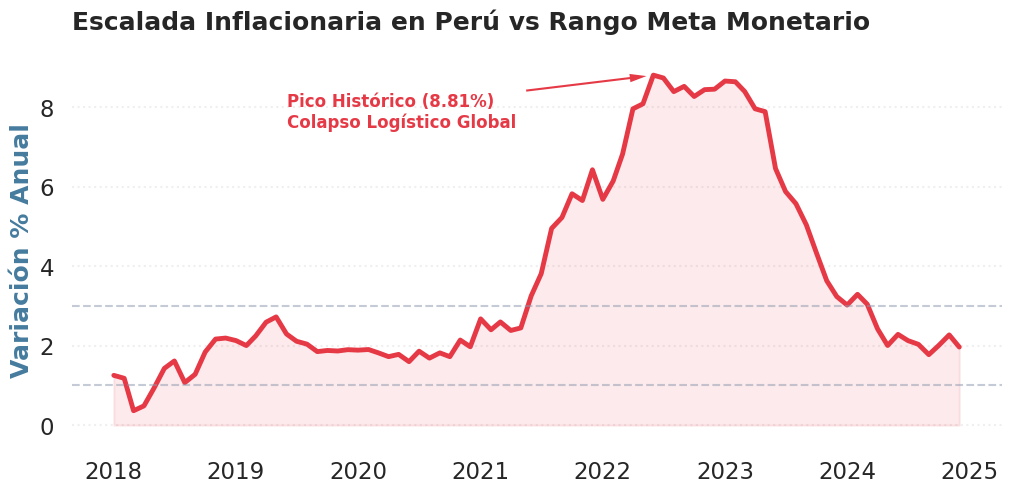


--------------------------------------------------------------------------------



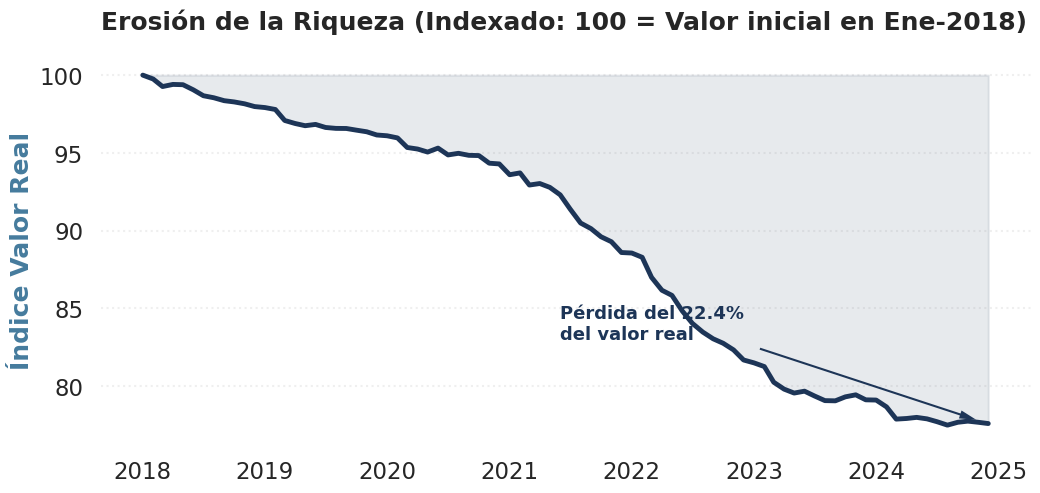

In [2]:
# 👁️ [CAPA 1] Impacto Visual Ejecutivo
sns.set_theme(style="white", context="talk") # Minimalismo (Eliminamos grid visual excesivo)

# Colores Corporativos (1-2 main tones)
color_inf = "#E63946"  # Red/Coral
color_poder = "#1D3557" # Navy Blue

fig1, ax1 = plt.subplots(figsize=(12, 5))
sns.lineplot(data=clean, x="fecha", y="inflacion_anual", ax=ax1, color=color_inf, linewidth=3.5)
ax1.fill_between(clean["fecha"], clean["inflacion_anual"], color=color_inf, alpha=0.10) # Menos opacidad, más pro

# Rango Meta (minimalista en gris)
ax1.axhline(1.0, color="#8D99AE", linestyle="--", alpha=0.5, linewidth=1.5)
ax1.axhline(3.0, color="#8D99AE", linestyle="--", alpha=0.5, linewidth=1.5)

# Anotación 1: Solo foco cardinal
ax1.annotate('Pico Histórico (8.81%)\nColapso Logístico Global',
             xy=(pd.to_datetime("2022-06-01"), 8.81), xytext=(pd.to_datetime("2019-06-01"), 7.5),
             arrowprops=dict(facecolor=color_inf, shrink=0.05, width=1.5, headwidth=6, edgecolor='none'),
             fontsize=12, fontweight='bold', color=color_inf)

ax1.set_title("Escalada Inflacionaria en Perú vs Rango Meta Monetario", fontweight="heavy", pad=20, loc='left')
ax1.set_ylabel("Variación % Anual", color="#457B9D", fontweight="bold")
ax1.set_xlabel("")
sns.despine(left=True, bottom=True) # Elimina los bordes totalmente (Top-tier aesthetic)
plt.grid(axis='y', linestyle='dotted', alpha=0.3)
plt.show()

print("\n" + "-" * 80 + "\n") # Separador limpio entre gráficos

fig2, ax2 = plt.subplots(figsize=(12, 5))
sns.lineplot(data=clean, x="fecha", y="poder_adquisitivo_base100", ax=ax2, color=color_poder, linewidth=3.5)
ax2.fill_between(clean["fecha"], clean["poder_adquisitivo_base100"], 100, color=color_poder, alpha=0.10)

ax2.annotate('Pérdida del 22.4%\ndel valor real',
             xy=(pd.to_datetime("2024-12-01"), 77.59), xytext=(pd.to_datetime("2021-06-01"), 83),
             arrowprops=dict(facecolor=color_poder, shrink=0.05, width=1.5, headwidth=6, edgecolor='none'),
             fontsize=13, fontweight='bold', color=color_poder)

ax2.set_title("Erosión de la Riqueza (Indexado: 100 = Valor inicial en Ene-2018)", fontweight="heavy", pad=20, loc='left')
ax2.set_ylabel("Índice Valor Real", color="#457B9D", fontweight="bold")
ax2.set_xlabel("")
sns.despine(left=True, bottom=True)
plt.grid(axis='y', linestyle='dotted', alpha=0.3)
plt.show()


### 2. Profundidad Analítica (Deep Explanation)

Se le conoce a la inflación como el “impuesto más fuerte” sobre la riqueza. En el gráfico de Escalada Inflacionaria expuesto arriba, vemos un quiebre agresivo del mandato principal del Banco Central.

**La Crisis Inflacionaria Mundial (2021 - 2023):**

De 2021 a 2023, la inflación superó rápidamente el rango meta oficial del BCRP (1% - 3%). No sólo se trató de un fenómeno aislado peruano sino de un *shock estructural global* impulsado por:

- **Crisis Logística:** Disrupciones y sobrecostos por la reactivación asimétrica de las cadenas de suministro pos-Covid (Crisis de Contenedores).
- **Shocks Energéticos y de Alimentos:** El inicio de la guerra Rusia-Ucrania, que elevó el precio internacional de la urea, el petróleo crudo y de los granos clave, como el trigo y el maíz duro.
- **Inestabilidad Sociopolítica:** En 2023, protestas locales por la gobernabilidad del país bloquearon temporalmente corredores viales, impactando la cadena de perecibles y aumentando las presiones sobre los precios al por menor.

**Secuelas Permanentes e Impacto Directo (2024):**


Si bien la caída de la curva del IPC para volver al *rango meta sub-3%* en abril del 2024 es evidente (por la agresiva subida de tasas de interés de referencia por parte del BCRP que alcanzó picos restrictivos severos),
la segunda visualización (*Erosión de la Riqueza*) pone al desnudo un impacto crónico, con frecuencia malentendido:

> *«Aunque la inflación vuelve a niveles normales, los precios nominales no caen a los precios originales en una economía moderna. El daño en el nivel de precios se acumula para siempre.»*

En términos concretos: si se ahorró un capital de **100 soles estáticamente** al comienzo del año 2018, hoy su poder adquisitivo real es solamente de **77.6 soles**. Esto implica que, en un periodo de apenas seis años, el poder adquisitivo del peruano se evaporará de manera irreversible en más del **22%**.

### 3. Apéndice técnico. Pipeline de datos (Extracción y metodología)


Este informe no se hizo con extracción estática (datasets CSV previamente empaquetados). El presente análisis dispone de un **Pipeline Extractor** dinámico bajo lenguaje Python, desarrollado específicamente para inyectar conectores directos hacia los endpoints abiertos del Banco Central, lo que garantiza auditoría constante y actualización *Zero-Touch*.


**Detalles de la API BCRP:**

- Se utilizó `json` y `urllib.request` para obtener un *raw data endpoint* directamente desde `estadisticas.bcrp.gob.pe`.
- Extracción de la Serie **PN01273PM:** Indicador técnico de la Inflación interanual (IPC Lima Metropolitana).
- Serie extraída **PN38705PM:** Indicador macro del Índice de Precios al Consumidor (Base Dic 2021 = 100).

**Transformación y cálculo del índice deflactado real:**

Dentro del Módulo 1 (Celda de Descarga), aplicamos *Feature Engineering* aplicando una sencilla pero robusta transformación económica que nos dice la verdadera historia:

```python
# Métrica económica secreta que impulsa este reporte
ipc_base = clean["indice_precios"].iloc[0]
clean["poder_adquisitivo_base100"] = 100 * (ipc_base / clean["indice_precios"])
```
*La variable* `ipc_base` *actúa como el ancla (el kilómetro 0 del reloj del coche).* Al dividirlo bajo el actual *índice corrido de precios* y fijar base 100, logramos la verdadera visualización de la erosión monetaria.